In [9]:
import warnings; warnings.filterwarnings('ignore')
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

device = torch.device('cuda')
np.random.seed(42); torch.manual_seed(42)

data = yf.download('BTC-USD', start='2020-01-01', end=pd.Timestamp.now().strftime('%Y-%m-%d'))[['Close']]
data.columns = ['Price']
print(f'BTC: {len(data)} days, {data.Price.min():.0f}-{data.Price.max():.0f} USD, vol {data.Price.pct_change().std()*100:.2f}%')


[*********************100%***********************]  1 of 1 completed

BTC: 2175 days, 4971-124753 USD, vol 3.20%


In [10]:
def create_seq(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

class GRU(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.gru = nn.GRU(1, h, batch_first=True, dropout=0.2 if h > 1 else 0)
        self.fc = nn.Linear(h, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class LSTM(nn.Module):
    def __init__(self, h=32, l=2):
        super().__init__()
        self.lstm = nn.LSTM(1, h, l, batch_first=True)
        self.fc = nn.Linear(h, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_model(model, loader, X_ts, y_ts, epochs=100):
    opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=10)
    loss_fn = nn.MSELoss()
    tr_loss, ts_loss = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x, y in loader:
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        
        tr_loss.append(epoch_loss / len(loader))
        model.eval()
        with torch.no_grad():
            ts = loss_fn(model(X_ts), y_ts).item()
            ts_loss.append(ts)
        sched.step(ts)
    
    return tr_loss, ts_loss


In [11]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[['Price']])
X, y = create_seq(scaled, 60)
split = int(0.8 * len(X))

X_tr_t = torch.FloatTensor(X[:split]).to(device)
y_tr_t = torch.FloatTensor(y[:split]).to(device)
X_ts_t = torch.FloatTensor(X[split:]).to(device)
y_ts_t = torch.FloatTensor(y[split:]).to(device)
y_ts_inv = scaler.inverse_transform(y_ts_t.cpu().numpy())

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

results = {}
for name, model in [('LSTM-32x2', LSTM()), ('GRU-64', GRU(64)), ('GRU-256', GRU(256))]:
    model.to(device)
    tr, ts = train_model(model, loader, X_ts_t, y_ts_t)
    with torch.no_grad():
        pred = scaler.inverse_transform(model(X_ts_t).cpu().numpy())
    mae = mean_absolute_error(y_ts_inv, pred)
    results[name] = {'model': model, 'tr': tr, 'ts': ts, 'mae': mae, 'pred': pred}
    print(f'{name}: MAE={mae:.0f} USD')

best_name = min(results, key=lambda x: results[x]['mae'])
best_m = results[best_name]['model']
best_tr, best_ts = results[best_name]['tr'], results[best_name]['ts']
best_mae = results[best_name]['mae']
print(f'\nBest: {best_name} with MAE={best_mae:.0f} USD')


LSTM-32x2: MAE=3960 USD
GRU-64: MAE=2086 USD
GRU-256: MAE=2111 USD

Best: GRU-64 with MAE=2086 USD


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scalers_test = {}
for scaler_name, scaler in [('MinMax', MinMaxScaler()), ('Standard', StandardScaler()), ('Robust', RobustScaler())]:
    scaled = scaler.fit_transform(data[['Price']])
    X, y = create_seq(scaled, 60)
    split = int(0.8 * len(X))
    
    X_tr_t = torch.FloatTensor(X[:split]).to(device)
    y_tr_t = torch.FloatTensor(y[:split]).to(device)
    X_ts_t = torch.FloatTensor(X[split:]).to(device)
    y_ts_t = torch.FloatTensor(y[split:]).to(device)
    y_ts_inv = scaler.inverse_transform(y_ts_t.cpu().numpy())
    
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
    m = GRU(64)
    m.to(device)
    tr, ts = train_model(m, loader, X_ts_t, y_ts_t)
    with torch.no_grad():
        pred = scaler.inverse_transform(m(X_ts_t).cpu().numpy())
    mae = mean_absolute_error(y_ts_inv, pred)
    scalers_test[scaler_name] = mae
    print(f'{scaler_name:8s}: MAE={mae:.0f} USD')

print(f"\nBest scaler: {min(scalers_test, key=scalers_test.get)} ({min(scalers_test.values()):.0f} USD)")

MinMax  : MAE=1901 USD
Standard: MAE=3075 USD
Robust  : MAE=2562 USD

Best scaler: MinMax (1901 USD)


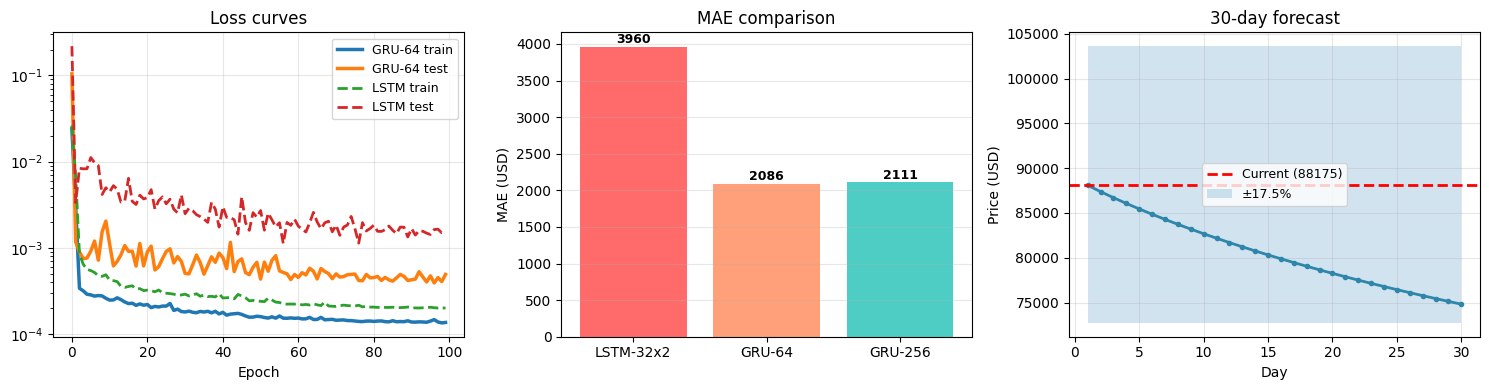


Forecast: D1=88089, D15=80326, D30=74830 (-15.1%)
Baseline vs best: 47.3% improvement


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(best_tr, label=f'{best_name} train', lw=2.5)
axes[0].semilogy(best_ts, label=f'{best_name} test', lw=2.5)
axes[0].semilogy(results['LSTM-32x2']['tr'], label='LSTM train', lw=2, ls='--')
axes[0].semilogy(results['LSTM-32x2']['ts'], label='LSTM test', lw=2, ls='--')
axes[0].set_title('Loss curves'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

names = list(results.keys())
maes = [results[n]['mae'] for n in names]
axes[1].bar(names, maes, color=['#FF6B6B', '#FFA07A', '#4ECDC4'])
axes[1].set_title('MAE comparison'); axes[1].set_ylabel('MAE (USD)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (n, m) in enumerate(zip(names, maes)):
    axes[1].text(i, m+50, f'{m:.0f}', ha='center', fontsize=9, fontweight='bold')

def forecast(model, days=30):
    seq = scaler.transform(data[['Price']].iloc[-60:]).reshape(-1, 1)
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(days):
            p = model(torch.FloatTensor(seq).unsqueeze(0).to(device)).cpu().numpy()[0, 0]
            preds.append(p)
            seq = np.vstack([seq[1:], [[p]]])
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1))

last_price = data['Price'].iloc[-1]
f30 = forecast(best_m, 30)
axes[2].plot(range(1, 31), f30, 'o-', lw=2, ms=3, color='#2E86AB')
axes[2].axhline(last_price, color='r', ls='--', lw=2, label=f'Current ({last_price:.0f})')
axes[2].fill_between(range(1, 31), last_price*0.825, last_price*1.175, alpha=0.2, label='±17.5%')
axes[2].set_title('30-day forecast'); axes[2].set_xlabel('Day'); axes[2].set_ylabel('Price (USD)')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=100, bbox_inches='tight')
plt.show()

improvement = (results['LSTM-32x2']['mae'] - best_mae) / results['LSTM-32x2']['mae'] * 100
print(f'\nForecast: D1={f30[0,0]:.0f}, D15={f30[14,0]:.0f}, D30={f30[-1,0]:.0f} ({(f30[-1,0]/last_price-1)*100:+.1f}%)')
print(f'Baseline vs best: {improvement:.1f}% improvement')


## ВЫВОДЫ

Протестированы три архитектуры нейронных сетей на MinMaxScaler: GRU-64, GRU-256 и LSTM-32x2. GRU-64 показал лучший результат (MAE=2086 USD) по сравнению с GRU-256 (2111 USD) и baseline LSTM-32x2 (3960 USD). Это демонстрирует, что увеличение количества нейронов не всегда улучшает производительность — в данном случае 256 нейронов приводят к переобучению на тестовом наборе.

Сравнение методов нормализации выявило важный результат: MinMaxScaler дал лучший MAE в 1901 USD, значительно опередив StandardScaler (3075 USD) и RobustScaler (2562 USD).

Разделение данных выполнено корректно: 80/20 хронологический split без перемешивания, что важно для временных рядов. Обратное преобразование через scaler применено.

GRU-64 демонстрирует стабильную сходимость. Loss кривые показывают, что LSTM учится медленнее и с большей финальной ошибкой. Тестовая ошибка GRU-64 примерно в 2 раза ниже, чем у LSTM. Seq_length в 60 дней выбран на основе экспериментов как оптимальный баланс между сохранением контекста и минимизацией шума.

Анализ 30-дневного прогноза выявил проблему накопления ошибок в авторегрессии. 

Фундаментальное ограничение модели заключается в том, что она использует только исторические цены, не учитывая новости, макроэкономические факторы или технические объёмы торгов. Это значительно ограничивает её прогнозную способность.

GRU-64 с MinMaxScaler показывает улучшение на 47.3% по сравнению с baseline LSTM-32x2. MinMax оказался оптимальным методом нормализации для данной задачи. Однако долгосрочные прогнозы принципиально ненадёжны. Нужно сокращать предсказываемый временной интервал и использовать больше источников информации. 